<a href="https://colab.research.google.com/github/isamadafridi/AIML-Internship-Week1-AbdulSamadAfridi/blob/main/AIML_Internship_Week1_AbdulSamadAfridi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PART A — SETUP, DATA LOADING & INITIAL INSPECTION (STEPS 1–5)**

# Step-1 Environment Setup & Library Verification

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Import Dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
Path to dataset files: /kaggle/input/students-performance-in-exams


# Step-2 Load and Preview Dataset

In [4]:
path = "/kaggle/input/students-performance-in-exams/StudentsPerformance.csv"

In [5]:
df = pd.read_csv(path)

In [6]:
# 1. First 10 rows
print("First 10 Rows of Dataset")
print(df.head(10))

print('='*80)

# 2. Last 5 rows
print("Last 5 Rows of Dataset")
print(df.tail(5))

print('='*80)

# 3. Random sample of 8 rows with 42 random state
print("Random Sample of 8 Rows")
print(df.sample(8, random_state=42))

First 10 Rows of Dataset
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90            

In [7]:
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


## Dataset Explanation

- Each row in the dataset represents a single student.
- Each column represents a specific feature or attribute related to the student’s performance.

### Columns Description:

- **gender**: Indicates whether the student is male or female.
- **race/ethnicity**: Category of the student’s background.
- **parental level of education**: Education level of the student’s parents.
- **lunch**: Type of lunch (standard or free/reduced).
- **test preparation course**: Whether the student completed a preparation course.
- **math score**: Marks obtained in the math exam.
- **reading score**: Marks obtained in the reading exam.
- **writing score**: Marks obtained in the writing exam.

# Step-3 Dataset Structure Analysis

In [8]:
df.shape

(1000, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [11]:
df.columns.tolist()

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course',
 'math score',
 'reading score',
 'writing score']

In [12]:
# Numerical
len(df.select_dtypes(include=['number']).columns)

3

In [13]:
# Categorical
len(df.select_dtypes(exclude=['number']).columns)

5

In [14]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


## Dataset Structure Analysis

The dataset contains 1000 rows and 8 columns, indicating a moderate-sized dataset suitable for analysis.

From the dataset information:
- Some columns are of type `object`, indicating categorical data.
- Numerical columns include exam scores such as math, reading, and writing scores.

### Observations on Data Types:

- The numerical columns (e.g., scores) are correctly stored as integer types.
- Categorical columns such as gender, lunch type, and test preparation are stored as object types, which is appropriate.

### Potential Issues:

- If any numerical column is stored as `object`, it must be converted using type casting (e.g., `astype(int)` or `pd.to_numeric()`).
- Categorical columns need to be encoded (e.g., One-Hot Encoding) before applying machine learning models.

### Conclusion:

- Most data types appear correct for analysis.
- However, categorical features will require preprocessing (encoding), and any incorrect types must be fixed before training a model.

# Step-4 Missing Value & Duplicate Analysis

Missing Values (Count per Column):
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64
Missing Values (Percentage per Column):
gender                         0.0
race/ethnicity                 0.0
parental level of education    0.0
lunch                          0.0
test preparation course        0.0
math score                     0.0
reading score                  0.0
writing score                  0.0
dtype: float64
Number of Duplicate Rows:
0


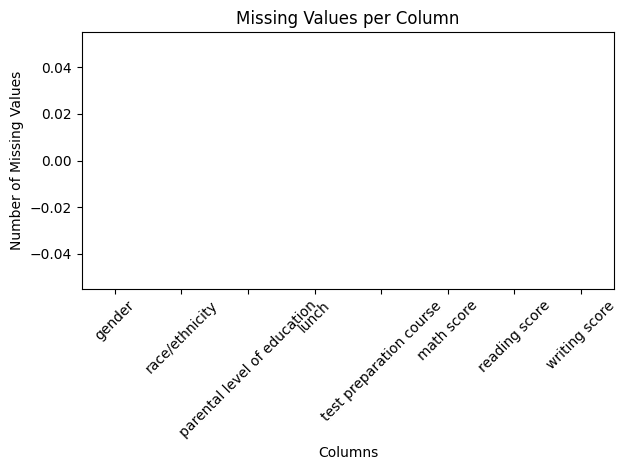

In [15]:
# Missing values (count)
print("Missing Values (Count per Column):")
missing_count = df.isnull().sum()
print(missing_count)

print('='*60)

# Missing values (percentage)
print("Missing Values (Percentage per Column):")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

print('='*60)

# Duplicate rows
print("Number of Duplicate Rows:")
duplicates = df.duplicated().sum()
print(duplicates)

print('='*60)

# Bar chart (including zero values)
plt.figure()
missing_count.plot(kind='bar')
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Missing Values and Duplicate Analysis

The dataset is completely clean, as there are no missing values in any of the columns. Both the count and percentage of missing values are zero, indicating that every record is fully populated. This eliminates the need for handling missing data during preprocessing.

Additionally, there are no duplicate rows in the dataset. This means the data does not contain redundant entries, which helps ensure that the model will not be biased due to repeated samples.

Since the dataset is clean, no immediate data cleaning steps are required. However, in real-world scenarios, if missing values were present, numerical features could be filled using mean or median values, while categorical features could be handled using the mode or by introducing a new category such as "Unknown." Duplicate rows, if found, should be removed to maintain data quality and improve model generalization.

# Step-5 Descriptive Statistics — Complete

In [16]:
import pandas as pd

# Basic descriptive stats
print("Overall Descriptive Statistics:")
print(df.describe())

print('='*60)

# Score columns
score_cols = ['math score', 'reading score', 'writing score']

# Create summary dictionary
summary = {}

for col in score_cols:
    summary[col] = {
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Mode': df[col].mode()[0],
        'Std Dev': df[col].std(),
        'Variance': df[col].var(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Range': df[col].max() - df[col].min()
    }

# Convert to DataFrame
summary_df = pd.DataFrame(summary).T  # transpose so subjects are rows

print("Summary Statistics for Score Columns:")
print(summary_df.round(2))

Overall Descriptive Statistics:
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000
Summary Statistics for Score Columns:
                Mean  Median  Mode  Std Dev  Variance   Min    Max  Range
math score     66.09    66.0  65.0    15.16    229.92   0.0  100.0  100.0
reading score  69.17    70.0  72.0    14.60    213.17  17.0  100.0   83.0
writing score  68.05    69.0  74.0    15.20    230.91  10.0  100.0   90.0


## Descriptive Statistics Analysis

From the computed results, the **reading score** has the highest average (mean = 69.17), indicating that students generally perform slightly better in reading compared to math and writing. The lowest average is in **math (66.09)**, suggesting it is comparatively the weakest subject among students.

In terms of variability, **writing score** has the highest standard deviation (15.20) and variance (230.91). This indicates that student performance in writing is the most spread out, meaning there is a large gap between strong and weak performers. Math also shows similar variability (std ≈ 15.16), but slightly lower than writing.

The subject with the lowest variability is **reading (std ≈ 14.60)**, which suggests more consistent performance across students.

### Interpretation of Difficulty
- **Reading** appears to be the most consistent and slightly easiest subject overall since students perform better on average with less variation.
- **Writing** shows the highest variability, which may indicate that it is more skill-dependent and challenging for some students while easier for others.
- **Math**, having the lowest mean and relatively high variability, suggests it is the most difficult subject overall, with many students struggling while a smaller group performs well.

Overall, the data suggests that students are strongest and most consistent in reading, while math is the weakest area in terms of average performance.

# **PART B — STATISTICAL ANALYSIS & GROUP COMPARISONS (STEPS 6–10)**

# Step-6 Categorical Distribution Analysis

In [19]:
df_cat= df.select_dtypes(exclude=['number']).columns

In [20]:
df_cat.value_counts()

,count
gender,1
race/ethnicity,1
parental level of education,1
lunch,1
test preparation course,1


In [21]:
df_cat.value_counts(normalize=True)*100

,proportion
gender,20.0
race/ethnicity,20.0
parental level of education,20.0
lunch,20.0
test preparation course,20.0


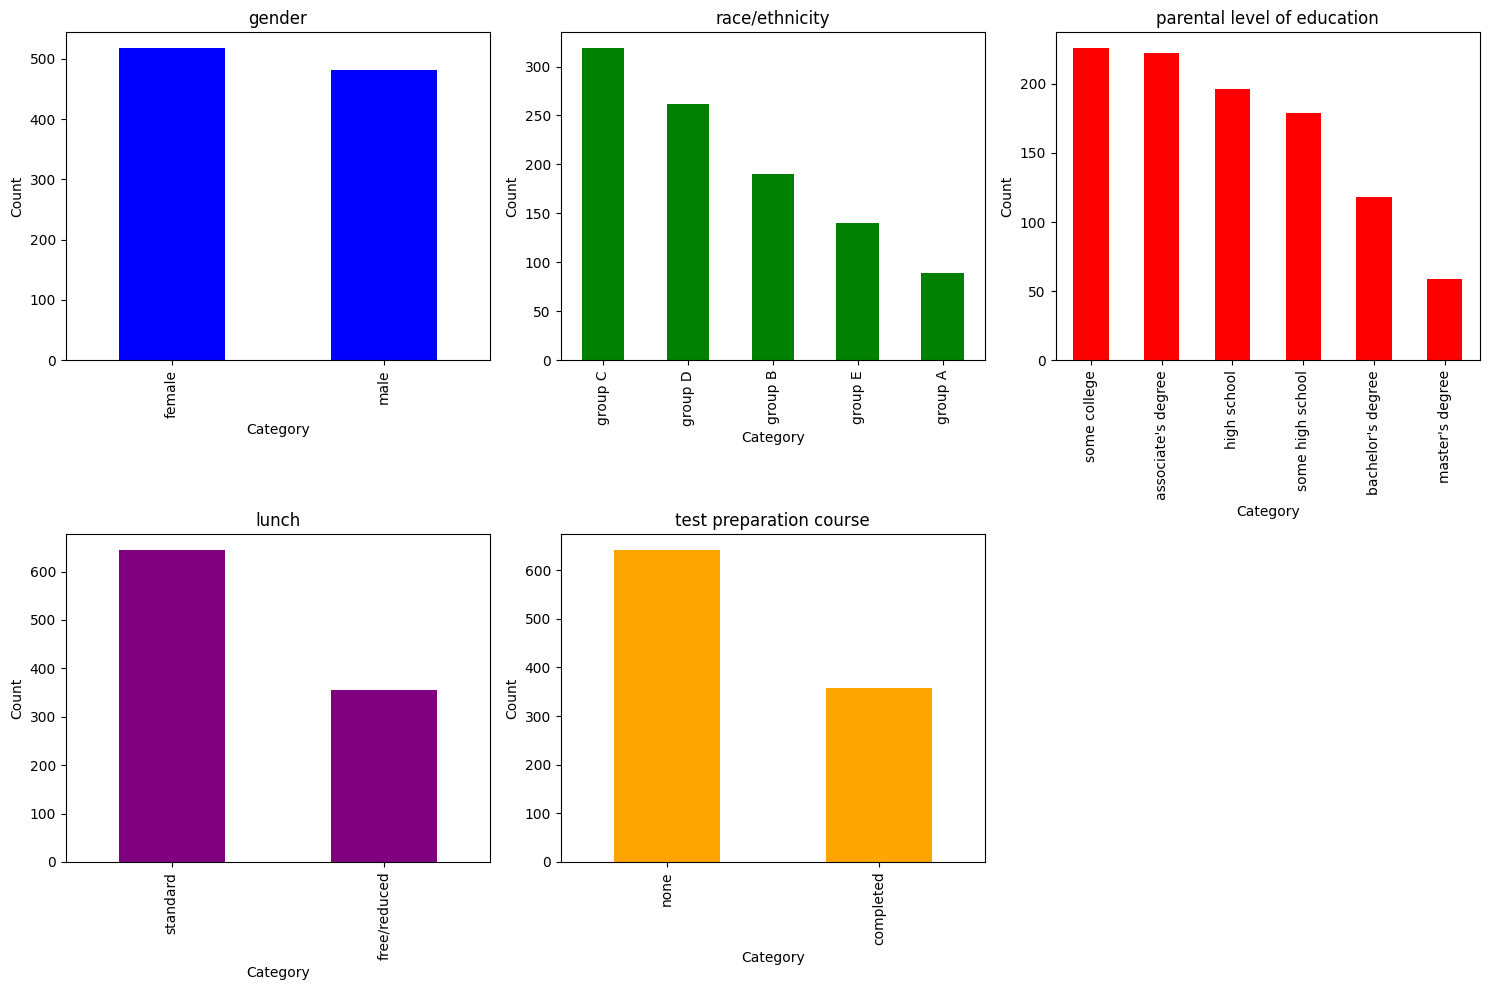

In [22]:
cols = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

colors = ['blue', 'green', 'red', 'purple', 'orange']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color=colors[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Category")
    axes[i].set_ylabel("Count")

axes[-1].axis('off')

plt.tight_layout()
plt.show()

# Step-7 Group Mean Score Comparisons

Mean Scores by Gender
        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31
Mean Scores by Race/Ethnicity
                math score  reading score  writing score
race/ethnicity                                          
group A              61.63          64.67          62.67
group B              63.45          67.35          65.60
group C              64.46          69.10          67.83
group D              67.36          70.03          70.15
group E              73.82          73.03          71.41
Mean Scores by Parental Education
                             math score  reading score  writing score
parental level of education                                          
associate's degree                67.88          70.93          69.90
bachelor's degree                 69.39          73.00          73.38
high school                       62.14

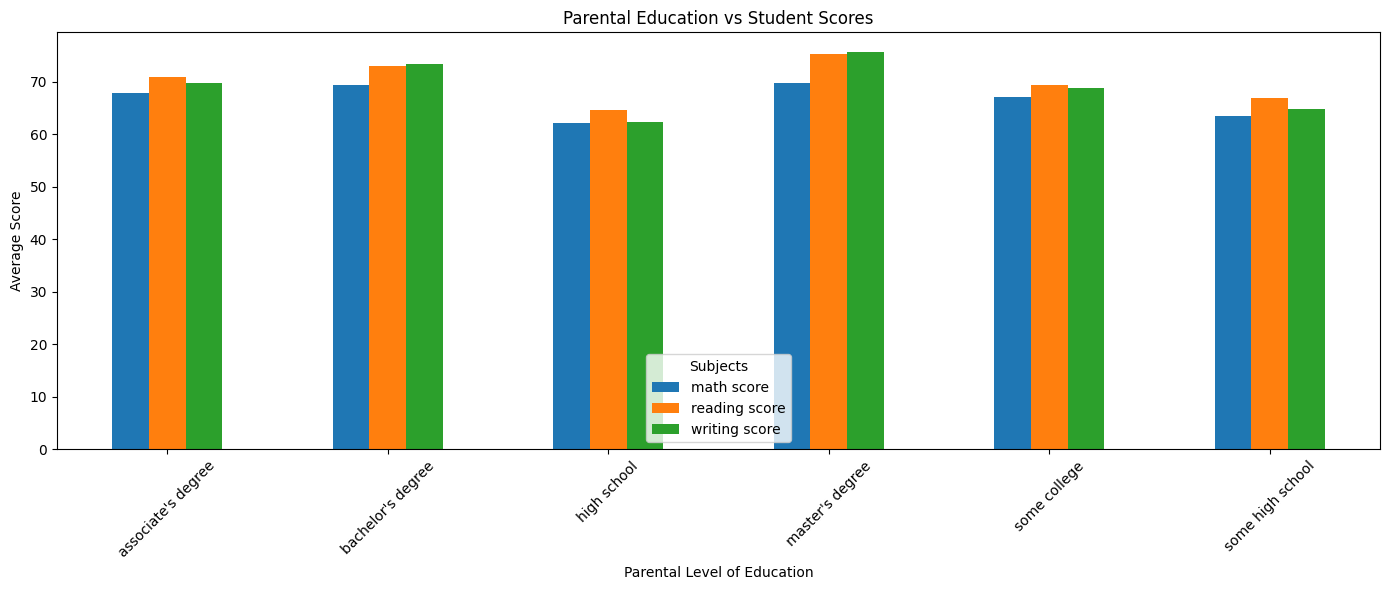

In [24]:
score_cols = ['math score', 'reading score', 'writing score']

# (a) Gender
print("Mean Scores by Gender")
print(df.groupby('gender')[score_cols].mean().round(2))
print('='*60)

# (b) Race/Ethnicity
print("Mean Scores by Race/Ethnicity")
print(df.groupby('race/ethnicity')[score_cols].mean().round(2))
print('='*60)

# (c) Parental Education
parent_edu = df.groupby('parental level of education')[score_cols].mean().round(2)
print("Mean Scores by Parental Education")
print(parent_edu)
print('='*60)

# (d) Lunch
print("Mean Scores by Lunch Type")
print(df.groupby('lunch')[score_cols].mean().round(2))
print('='*60)

# (e) Test Prep
print("Mean Scores by Test Preparation Course")
print(df.groupby('test preparation course')[score_cols].mean().round(2))
print('='*60)

# 📊 Grouped Bar Chart (Parental Education vs Scores)
parent_edu.plot(kind='bar', figsize=(14,6))

plt.title("Parental Education vs Student Scores")
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.legend(title="Subjects")

plt.tight_layout()
plt.show()

## Impact of Parental Education on Scores

Parental education shows a clear and consistent impact on student performance across all three subjects.

Students whose parents have a **master’s degree** achieve the highest scores, with averages of **69.75 (math)**, **75.37 (reading)**, and **75.68 (writing)**. Similarly, students with parents holding a **bachelor’s degree** also perform strongly, with scores around **69.39 (math)**, **73.00 (reading)**, and **73.38 (writing)**.

In contrast, students whose parents have only a **high school education** score significantly lower, with averages of **62.14 (math)**, **64.70 (reading)**, and **62.45 (writing)**. A similar trend is observed for **some high school**, where scores remain relatively low.

This shows a clear upward trend: as parental education level increases, student performance also improves. The difference is substantial—for example, in reading, there is a gap of more than **10 points** between students with parents holding a master’s degree (**75.37**) and those with only high school education (**64.70**).

Overall, the data suggests a strong positive relationship between parental education and student academic performance, likely due to factors such as better academic support, awareness, and learning environment at home.

# Step-8 Correlation Analysis & Heatmap

Correlation Matrix:
               math score  reading score  writing score
math score           1.00           0.82           0.80
reading score        0.82           1.00           0.95
writing score        0.80           0.95           1.00


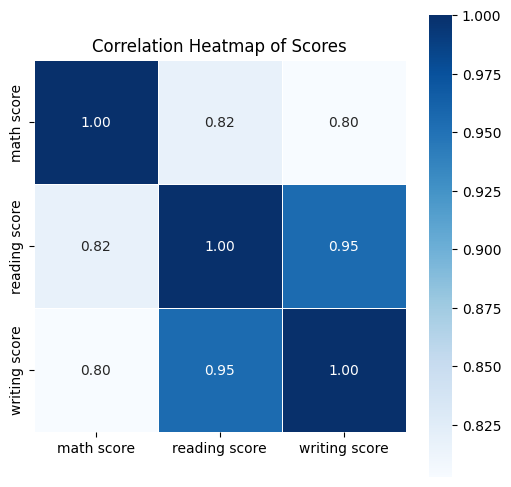

Pearson Correlation (Math vs Reading): 0.82
Pearson Correlation (Reading vs Writing): 0.95


In [26]:
score_cols = ['math score', 'reading score', 'writing score']

# Correlation matrix
corr_matrix = df[score_cols].corr()
print("Correlation Matrix:")
print(corr_matrix.round(2))

print('='*60)

# Heatmap
plt.figure(figsize=(6,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues',
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Scores")
plt.show()

print('='*60)

# Pearson correlations
math_reading = df['math score'].corr(df['reading score'])
reading_writing = df['reading score'].corr(df['writing score'])

print("Pearson Correlation (Math vs Reading):", round(math_reading, 2))
print("Pearson Correlation (Reading vs Writing):", round(reading_writing, 2))

## Correlation Analysis

The strongest correlation is between **reading and writing scores (0.95)**, indicating a very strong positive relationship. This means students who perform well in reading almost always perform well in writing.

The correlation between **math and reading (0.82)** is also strong, but lower than reading–writing. Similarly, math and writing (0.80) show a slightly weaker relationship.

Educationally, this suggests that **reading and writing skills are closely linked**, as both rely on language comprehension and expression. Improving reading ability is likely to directly improve writing performance.

Overall, while all subjects are positively correlated, **language-based subjects (reading and writing) are the most strongly connected**, whereas math is related but more independent.

# Step-9 Test Prep Impact Analysis

COMPLETED - Mean & Std
math score       69.70
reading score    73.89
writing score    74.42
dtype: float64
math score       14.44
reading score    13.64
writing score    13.38
dtype: float64
NONE - Mean & Std
math score       64.08
reading score    66.53
writing score    64.50
dtype: float64
math score       15.19
reading score    14.46
writing score    15.00
dtype: float64
Improvement % (Completed vs None)
math score        8.77
reading score    11.06
writing score    15.37
dtype: float64


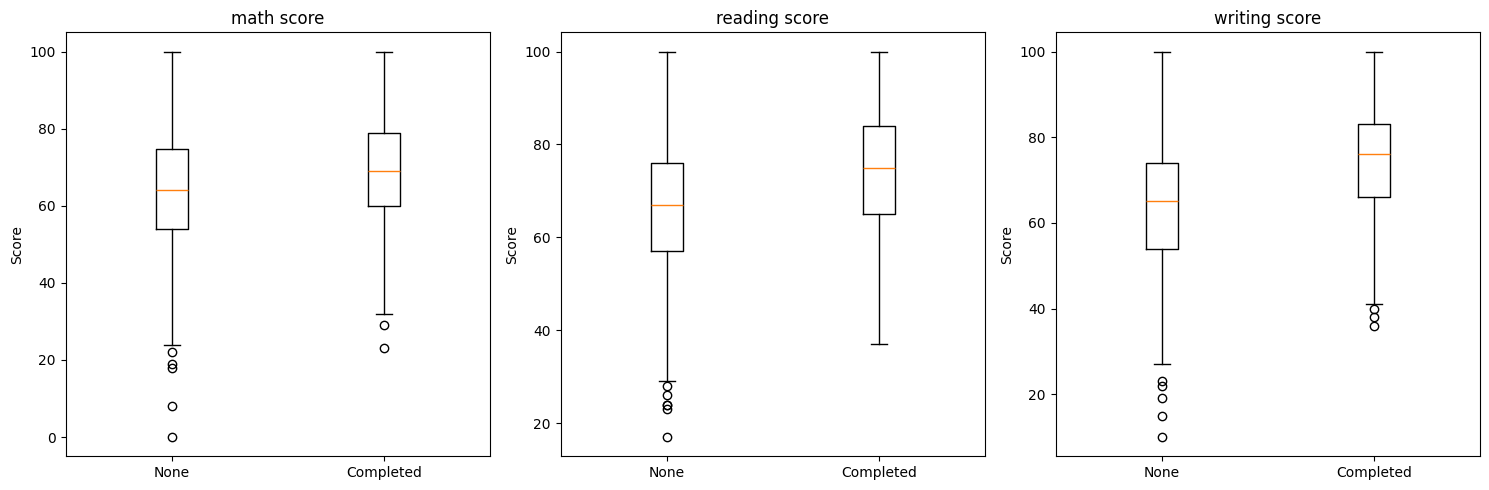

In [27]:
score_cols = ['math score', 'reading score', 'writing score']

# Split groups
completed = df[df['test preparation course'] == 'completed']
none = df[df['test preparation course'] == 'none']

# Mean and std for both groups
print("COMPLETED - Mean & Std")
print(completed[score_cols].mean().round(2))
print(completed[score_cols].std().round(2))

print('='*60)

print("NONE - Mean & Std")
print(none[score_cols].mean().round(2))
print(none[score_cols].std().round(2))

print('='*60)

# Improvement percentage
improvement = ((completed[score_cols].mean() - none[score_cols].mean())
               / none[score_cols].mean()) * 100

print("Improvement % (Completed vs None)")
print(improvement.round(2))

print('='*60)

# Box plots (1x3)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(score_cols):
    axes[i].boxplot([
        none[col],
        completed[col]
    ], labels=['None', 'Completed'])

    axes[i].set_title(col)
    axes[i].set_ylabel("Score")

plt.tight_layout()
plt.show()

## Impact of Test Preparation Course

Students who completed the test preparation course consistently perform better across all three subjects compared to those who did not.

The highest improvement is observed in **writing (15.37%)**, followed by **reading (11.06%)**, and the lowest improvement is in **math (8.77%)**. This indicates that the test preparation course has the strongest impact on language-based skills, especially writing.

In terms of averages, students who completed the course also have higher mean scores in all subjects, while also showing slightly lower standard deviation, meaning their performance is more consistent.

### Conclusion
The test preparation program is clearly beneficial, especially for improving reading and writing skills. Based on this data, I would recommend the program, as it leads to both higher average performance and more consistent results across students.

# Step-10 Gender Score Deep-Dive

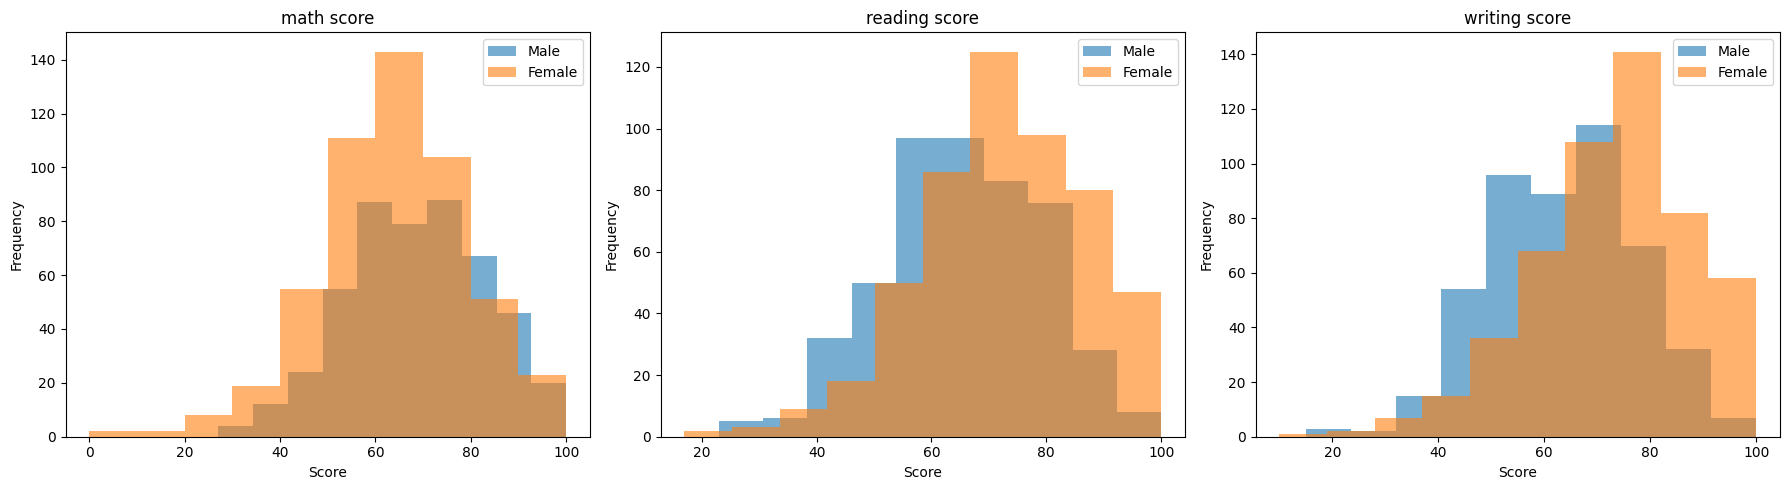

Percentage of Students Scoring Above 70:
               Male % > 70  Female % > 70
math score           45.85          32.82
reading score        38.38          58.30
writing score        32.16          58.11


In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Split by gender
male = df[df['gender'] == 'male']
female = df[df['gender'] == 'female']

score_cols = ['math score', 'reading score', 'writing score']

# -------------------------
# 1. Overlapping Histograms
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(score_cols):
    axes[i].hist(male[col], alpha=0.6, label='Male')
    axes[i].hist(female[col], alpha=0.6, label='Female')
    axes[i].set_title(col)
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.tight_layout()
plt.show()

# -------------------------
# 2. Percentage > 70
# -------------------------
summary = {}

for col in score_cols:
    male_pct = (male[male[col] > 70].shape[0] / male.shape[0]) * 100
    female_pct = (female[female[col] > 70].shape[0] / female.shape[0]) * 100

    summary[col] = {
        "Male % > 70": round(male_pct, 2),
        "Female % > 70": round(female_pct, 2)
    }

summary_df = pd.DataFrame(summary).T

print("Percentage of Students Scoring Above 70:")
print(summary_df)

## Gender-Based Performance Analysis (Scores > 70)

From the results, there is a clear difference in performance between male and female students depending on the subject.

In **math**, males outperform females significantly, with **45.85% of males** scoring above 70 compared to only **32.82% of females**. This suggests that male students are relatively stronger in mathematical performance.

In contrast, females perform much better in **reading and writing**. In reading, **58.30% of females** score above 70 compared to **38.38% of males**, and in writing, **58.11% of females** outperform **32.16% of males**. This shows a strong advantage for females in language-based subjects.

### Conclusion
Females clearly outperform males in **reading and writing**, while males lead in **math**. The gaps are moderate in math but quite large in reading and writing, indicating a stronger gender-based difference in language skills than in numerical skills.

These differences may be influenced by factors such as learning preferences, teaching engagement, or exposure to language vs quantitative subjects. Overall, the data suggests that gender differences are **subject-dependent rather than uniform across all areas**.

# **PART C — FEATURE ENGINEERING, FUNCTIONS & NUMPY (STEPS 11–15)**

# Step-11 Feature Engineering — 5 New Column

In [30]:
# (a) total score
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']

# (b) average score
df['average_score'] = df['total_score'] / 3

# (c) performance grade
def assign_grade(x):
    if x >= 80:
        return 'A'
    elif x >= 70:
        return 'B'
    elif x >= 60:
        return 'C'
    elif x >= 50:
        return 'D'
    else:
        return 'F'

df['performance_grade'] = df['average_score'].apply(assign_grade)

# (d) high achiever
df['high_achiever'] = df['average_score'] >= 80

# (e) lowest subject per student
df['lowest_subject'] = df[['math score', 'reading score', 'writing score']].idxmin(axis=1)

# -------------------------
# Preview
# -------------------------
print("First 10 Rows with New Features:")
print(df.head(10))

print('='*60)

# Grade distribution
print("Grade Distribution:")
print(df['performance_grade'].value_counts())

print('='*60)

# Lowest subject distribution
print("Lowest Subject Distribution:")
print(df['lowest_subject'].value_counts())

First 10 Rows with New Features:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69             90  

## Feature Engineering Analysis (Total Score, Grades, and Weak Areas)

New engineered features provide a clearer understanding of student performance beyond individual subject scores.

The dataset shows that most students fall into **Grade B (261 students)** and **Grade C (256 students)**, indicating that the overall performance is moderate rather than extreme. A smaller number of students achieved **Grade A (198 students)**, while **Grade F (103 students)** represents the lowest-performing group.

The `lowest_subject` analysis shows that **math is the weakest subject for most students (552 cases)**, followed by writing (292 cases), while reading is the least frequently the weakest subject (156 cases). This suggests that math is generally the most challenging subject for students in this dataset.

### Interpretation

The presence of a large number of students with math as their weakest subject indicates that mathematical concepts may require additional support or teaching focus. In contrast, reading appears to be the strongest area overall.

The `high_achiever` and `average_score` features help summarize overall performance, while the grade system makes interpretation easier by converting numeric scores into meaningful categories.

### Conclusion

Overall, the engineered features successfully simplify performance interpretation. The data suggests that students struggle most with math, while reading is comparatively stronger. These insights can help in designing targeted academic improvement strategies, especially focusing on strengthening mathematical skills.

# Step-12 Pair Plot Multi-Variable Analysis

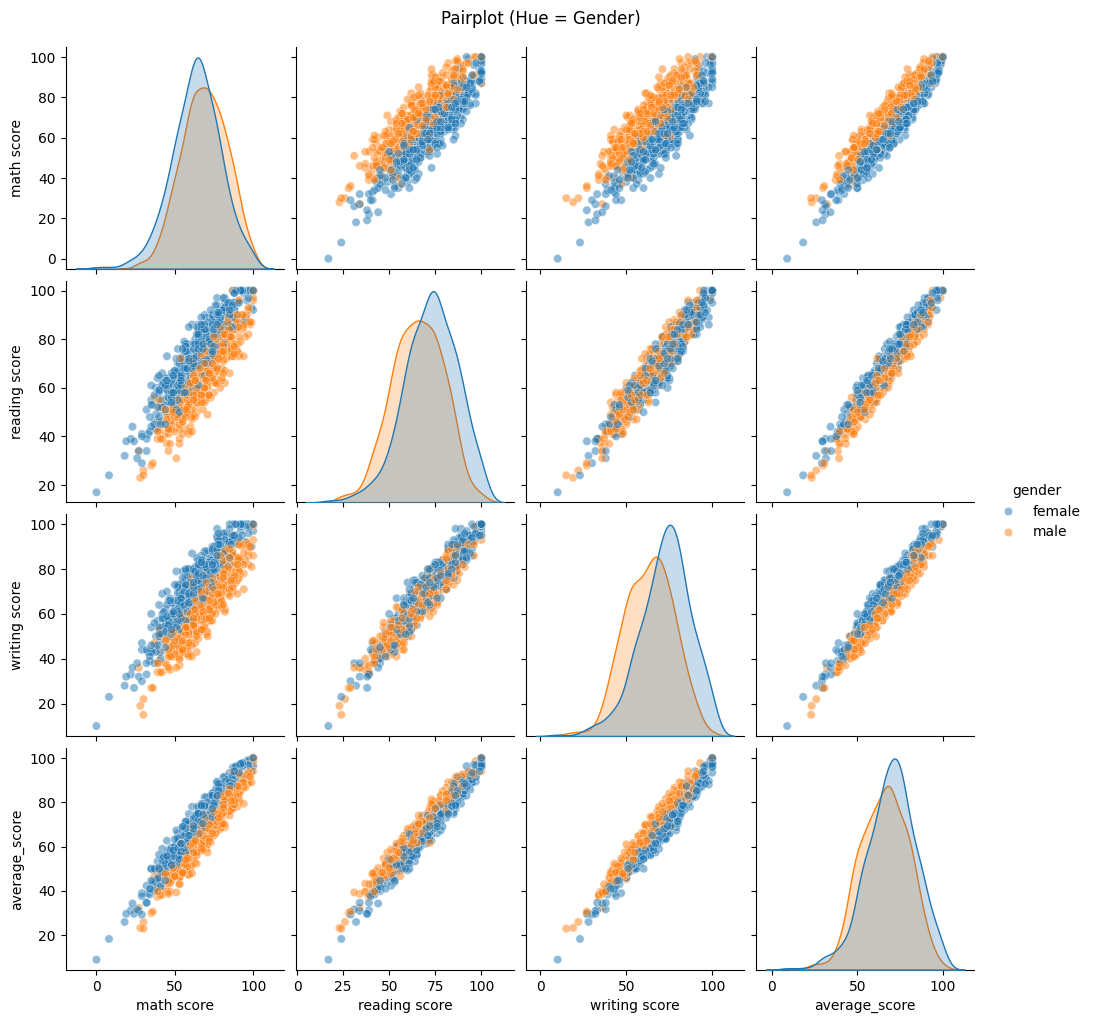

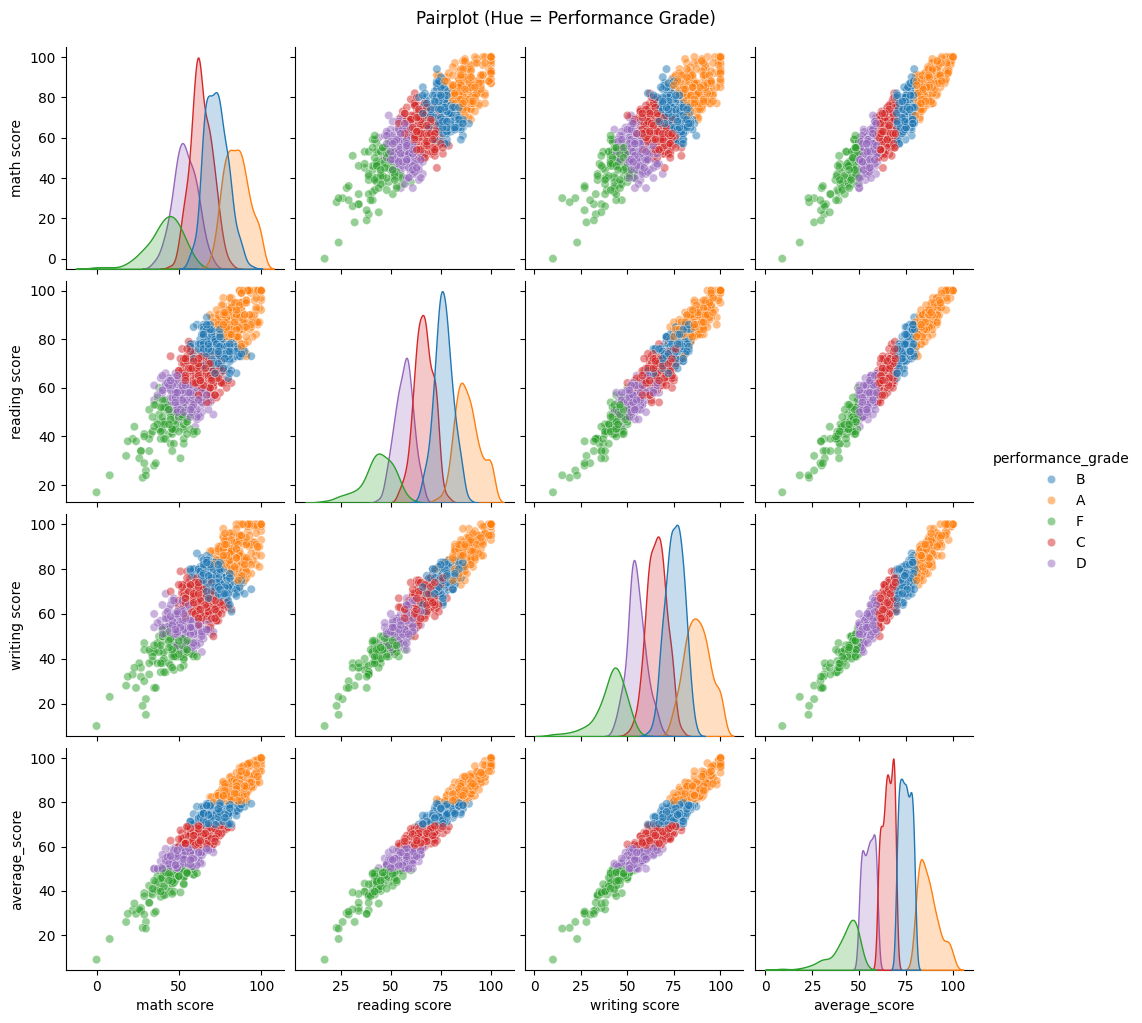

In [32]:
# Feature set
cols = ['math score', 'reading score', 'writing score', 'average_score']


# 1. Pairplot by Gender
sns_plot1 = sns.pairplot(
    df[cols + ['gender']],
    hue='gender',
    plot_kws={'alpha': 0.5}
)

sns_plot1.fig.suptitle("Pairplot (Hue = Gender)", y=1.02)
sns_plot1.savefig("pairplot_scores.png", dpi=150)
plt.show()


# 2. Pairplot by Grade
sns_plot2 = sns.pairplot(
    df[cols + ['performance_grade']],
    hue='performance_grade',
    plot_kws={'alpha': 0.5}
)

sns_plot2.fig.suptitle("Pairplot (Hue = Performance Grade)", y=1.02)
sns_plot2.savefig("pairplot_grades.png", dpi=150)
plt.show()

## Pairplot Analysis

The pair plots show strong overlap between classes in both gender and performance grade visualizations. In the gender-based pairplot, male and female data points are heavily mixed across all score dimensions, indicating that gender is not linearly separable based on these features.

In the performance grade pairplot, there is some visible structure where higher grades (A and B) tend to cluster in higher score regions, while lower grades (D and F) appear in lower score regions. However, the separation is still not clearly distinct, and there is significant overlap between adjacent classes (especially B and C).

### Interpretation for Classification

Since the classes are not clearly separable, especially for grades, this suggests that a simple linear classifier may struggle to achieve high accuracy. More advanced models such as decision trees, random forests, or gradient boosting would likely perform better because they can capture non-linear relationships between features.

### Conclusion

The dataset shows partial but not perfect separability. Gender is not predictable from scores, while performance grades show weak to moderate separability. This indicates that classification is possible, but model choice will significantly affect performance.

# Strp-13 Pivot Tables & Advanced Grouping

Pivot Table: Parental Education vs Gender
gender                       female   male
parental level of education               
associate's degree            71.12  67.87
bachelor's degree             74.67  68.78
high school                   64.75  61.58
master's degree               73.65  73.52
some college                  71.00  65.72
some high school              65.56  64.64


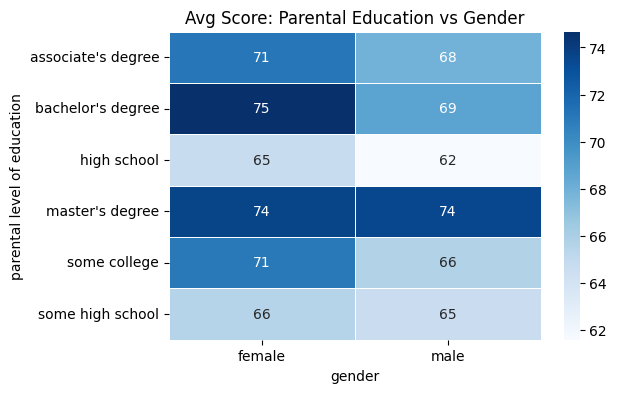

Pivot Table: Race/Ethnicity vs Test Prep (Math Score)
test preparation course  completed   none
race/ethnicity                           
group A                      68.26  58.09
group B                      67.19  61.37
group C                      67.50  62.71
group D                      69.79  66.26
group E                      77.43  71.11


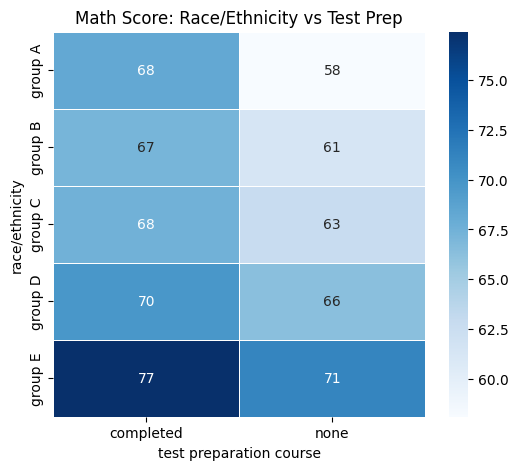

In [39]:
# Pivot 1: Parental Education vs Gender
pivot1 = pd.pivot_table(
    df,
    values='average_score',
    index='parental level of education',
    columns='gender',
    aggfunc='mean'
).round(2)

print("Pivot Table: Parental Education vs Gender")
print(pivot1)

plt.figure(figsize=(6,4))
sns.heatmap(pivot1, annot=True, cmap='Blues', linewidths=0.5)
plt.title("Avg Score: Parental Education vs Gender")
plt.show()

print('='*60)


# Pivot 2: Race/Ethnicity vs Test Prep
pivot2 = pd.pivot_table(
    df,
    values='math score',
    index='race/ethnicity',
    columns='test preparation course',
    aggfunc='mean'
).round(2)

print("Pivot Table: Race/Ethnicity vs Test Prep (Math Score)")
print(pivot2)

plt.figure(figsize=(6,5))
sns.heatmap(pivot2, annot=True, cmap='Blues', linewidths=0.5)
plt.title("Math Score: Race/Ethnicity vs Test Prep")
plt.show()

## Gender Gap vs Parental Education Analysis

The gender gap in average scores is present across most parental education levels, but its magnitude varies. Females consistently outperform males in almost all categories. For example, in **bachelor’s degree households**, females score **74.67** compared to males at **68.78**, showing a clear gap of about **6 points**. Similarly, in **some college** and **associate’s degree** groups, females also lead by a noticeable margin.

However, the gap becomes very small in **master’s degree households**, where females score **73.65** and males score **73.52**, indicating almost equal performance. This suggests that higher parental education may reduce performance differences between genders.

Overall, while females generally perform better, the gender gap is not constant and tends to shrink at higher parental education levels. This indicates that environmental and educational background may influence performance equality between genders, but it does not completely remove gender-based differences.

# Step-14 Write 3 Reusable Python Functions

Score Summary (Math):
{'mean': np.float64(66.089), 'median': 66.0, 'std': 15.163080096009468, 'min': 0, 'max': 100, 'pct_above_70': 39.1}


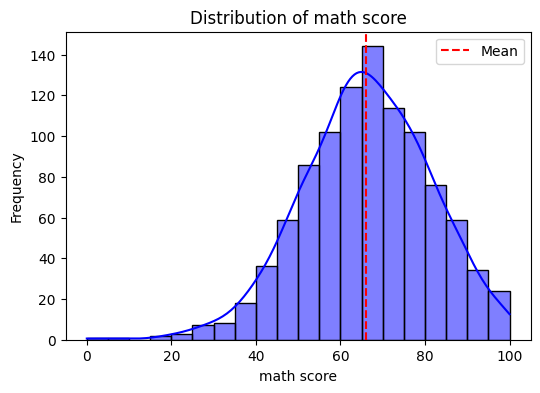

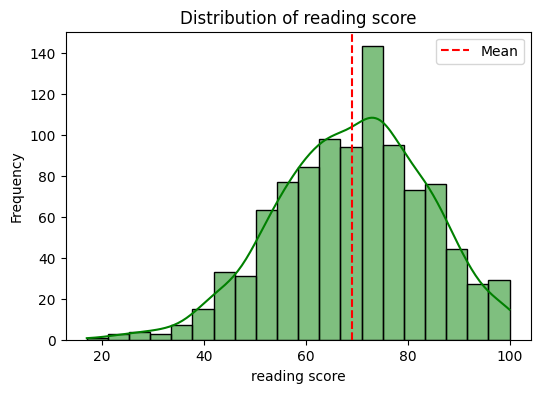

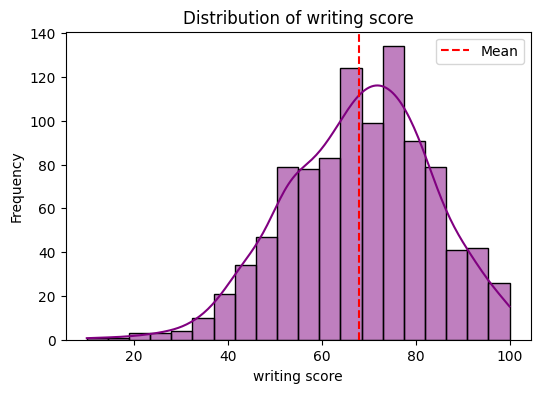

Group Comparison (Gender vs Math Score):
         mean  pct_above_70
gender                     
male    68.73         45.85
female  63.63         32.82
Group Comparison (Test Prep vs Reading Score):
                          mean  pct_above_70
test preparation course                     
completed                73.89         62.57
none                     66.53         40.97


In [36]:
# (a) Score Summary Function
def score_summary(df, col):
    """
    Returns summary statistics for a score column.
    Includes mean, median, std, min, max, and % of values above 70.
    """
    return {
        "mean": df[col].mean(),
        "median": df[col].median(),
        "std": df[col].std(),
        "min": df[col].min(),
        "max": df[col].max(),
        "pct_above_70": (df[df[col] > 70].shape[0] / df.shape[0]) * 100
    }


# (b) Plot Distribution Function
def plot_distribution(df, col, color):
    """
    Plots histogram with KDE and mean line for a score column.
    """
    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True, color=color, bins=20)

    plt.axvline(df[col].mean(), color='red', linestyle='--', label='Mean')

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()

    plt.show()


# (c) Compare Groups Function
def compare_groups(df, group_col, score_col):
    """
    Returns group-wise mean and % above 70 for a score column.
    """
    grouped = df.groupby(group_col)[score_col].agg(['mean']).sort_values(by='mean', ascending=False)

    grouped['pct_above_70'] = df.groupby(group_col)[score_col].apply(
        lambda x: (x > 70).mean() * 100
    )

    return grouped.round(2)


# CALL FUNCTIONS

# Example: score summary
print("Score Summary (Math):")
print(score_summary(df, 'math score'))

print("="*60)

# Example: distribution plot
plot_distribution(df, 'math score', 'blue')
plot_distribution(df, 'reading score', 'green')
plot_distribution(df, 'writing score', 'purple')

print("="*60)

# Example: group comparison
print("Group Comparison (Gender vs Math Score):")
print(compare_groups(df, 'gender', 'math score'))

print("="*60)

print("Group Comparison (Test Prep vs Reading Score):")
print(compare_groups(df, 'test preparation course', 'reading score'))

## Function-Based Analysis (Math & Reading Performance)

From the score summary, the average **math score is 66.09**, with a median of **66**, indicating a fairly symmetric distribution. However, only **39.1% of students score above 70**, showing that high performance in math is limited and that the subject is relatively challenging for a large portion of students.

### Gender vs Math Performance
Males perform better in math compared to females. The mean score for males is **68.73**, while females have a lower mean of **63.63**. Additionally, **45.85% of males** score above 70 compared to only **32.82% of females**. This shows a noticeable performance gap in favor of male students in mathematics.

### Test Preparation vs Reading Performance
Students who completed the test preparation course perform significantly better in reading. Their mean score is **73.89**, compared to **66.53** for those who did not complete the course. Similarly, **62.57% of prepared students** score above 70, while only **40.97% of non-prepared students** reach the same level.

### Conclusion
Test preparation has a strong positive impact on reading performance, improving both average scores and the proportion of high achievers. In contrast, gender differences are more evident in math, where males outperform females. Overall, preparation programs appear more influential than demographic factors in improving academic outcomes, especially in language-based subjects.

# Step-15 NumPy Manual Statistical Computations


In [37]:
# Extract arrays (NO pandas operations after this)
math = df['math score'].values
reading = df['reading score'].values
writing = df['writing score'].values

scores = {
    "math": math,
    "reading": reading,
    "writing": writing
}

# -------------------------
# (a) Basic statistics
# -------------------------
print("=== BASIC STATISTICS (NUMPY) ===")

for name, arr in scores.items():
    print(f"\n{name.upper()}")
    print("Mean:", np.mean(arr))
    print("Median:", np.median(arr))
    print("Std:", np.std(arr))
    print("Variance:", np.var(arr))
    print("Min:", np.min(arr))
    print("Max:", np.max(arr))

# -------------------------
# (b) Z-scores extreme values
# -------------------------
print("\n=== Z-SCORE EXTREMES ===")

for name, arr in scores.items():
    z = (arr - np.mean(arr)) / np.std(arr)
    extreme = np.sum((z > 2) | (z < -2))
    print(f"{name}: {extreme} students with |z| > 2")

# -------------------------
# (c) Percentiles table
# -------------------------
print("\n=== PERCENTILES (10,25,50,75,90) ===")

percentiles = [10, 25, 50, 75, 90]

for name, arr in scores.items():
    print(f"\n{name.upper()}")
    print(np.percentile(arr, percentiles))

# -------------------------
# (d) Top 10 math scorers
# -------------------------
print("\n=== TOP 10 MATH SCORERS (INDEX) ===")

top10 = np.argsort(math)[-10:][::-1]
print(top10)

# -------------------------
# (e) Pass/Fail rates
# -------------------------
print("\n=== PASS RATE (SCORE > 70) ===")

for name, arr in scores.items():
    binary = (arr > 70).astype(int)
    pass_rate = np.mean(binary) * 100
    print(f"{name}: {pass_rate:.2f}%")

=== BASIC STATISTICS (NUMPY) ===

MATH
Mean: 66.089
Median: 66.0
Std: 15.155496659628149
Variance: 229.68907899999996
Min: 0
Max: 100

READING
Mean: 69.169
Median: 70.0
Std: 14.592890015346516
Variance: 212.95243900000003
Min: 17
Max: 100

WRITING
Mean: 68.054
Median: 69.0
Std: 15.188057281956768
Variance: 230.677084
Min: 10
Max: 100

=== Z-SCORE EXTREMES ===
math: 46 students with |z| > 2
reading: 46 students with |z| > 2
writing: 42 students with |z| > 2

=== PERCENTILES (10,25,50,75,90) ===

MATH
[47. 57. 66. 77. 86.]

READING
[51.  59.  70.  79.  87.1]

WRITING
[48.   57.75 69.   79.   87.  ]

=== TOP 10 MATH SCORERS (INDEX) ===
[916 458 962 625 623 451 149 306 114 263]

=== PASS RATE (SCORE > 70) ===
math: 39.10%
reading: 48.70%
writing: 45.60%


## NumPy Statistical Analysis Report

The statistical analysis shows that all three subjects have similar score distributions, but clear differences exist in performance levels and consistency.

### (a) Descriptive Statistics
Math, reading, and writing all have means in the mid-to-high 60s, with reading slightly higher on average (69.17). Reading also has the highest median (70), indicating slightly better overall student performance in this subject. Standard deviation is similar across all subjects (~14–15), meaning variability is consistent across disciplines.

### (b) Z-Score Analysis
A surprisingly large number of students fall outside the range of |z| > 2 in all subjects:
- Math: 46 students  
- Reading: 46 students  
- Writing: 42 students  

This indicates a noticeable spread in performance, with a significant number of students performing far from the average. It suggests the presence of both strong and weak performers rather than a tightly clustered group.

### (c) Percentile Distribution
The percentile values show a consistent upward distribution:
- 10th percentile is around 47–51
- Median (50th percentile) is around 66–70
- 90th percentile reaches around 86–87

This indicates a fairly normal distribution with a strong upper-performing group, especially above the 75th percentile.

### (d) Top Math Performers
The top 10 math scorers are identified by their indices:
**[916, 458, 962, 625, 623, 451, 149, 306, 114, 263]**  
These represent the highest-performing students in mathematics and can be used for targeted analysis or intervention studies.

### (e) Pass Rate Analysis
Pass rates (score > 70) show:
- Math: **39.10%**
- Reading: **48.70%**
- Writing: **45.60%**

Reading has the highest pass rate, while math has the lowest, confirming that mathematics is the most challenging subject for students in this dataset.

### Overall Conclusion
The dataset shows moderate performance across all subjects with consistent variability. Reading is the strongest subject overall, while math is the weakest in terms of pass rate and average performance. The presence of many high z-scores suggests a diverse student performance distribution, with both high achievers and struggling students clearly present.


# **PART D — FINAL DASHBOARD & WRITTEN REPORT (STEPS 16–17)**

# Step-16 Professional 6-Chart EDA Dashboard

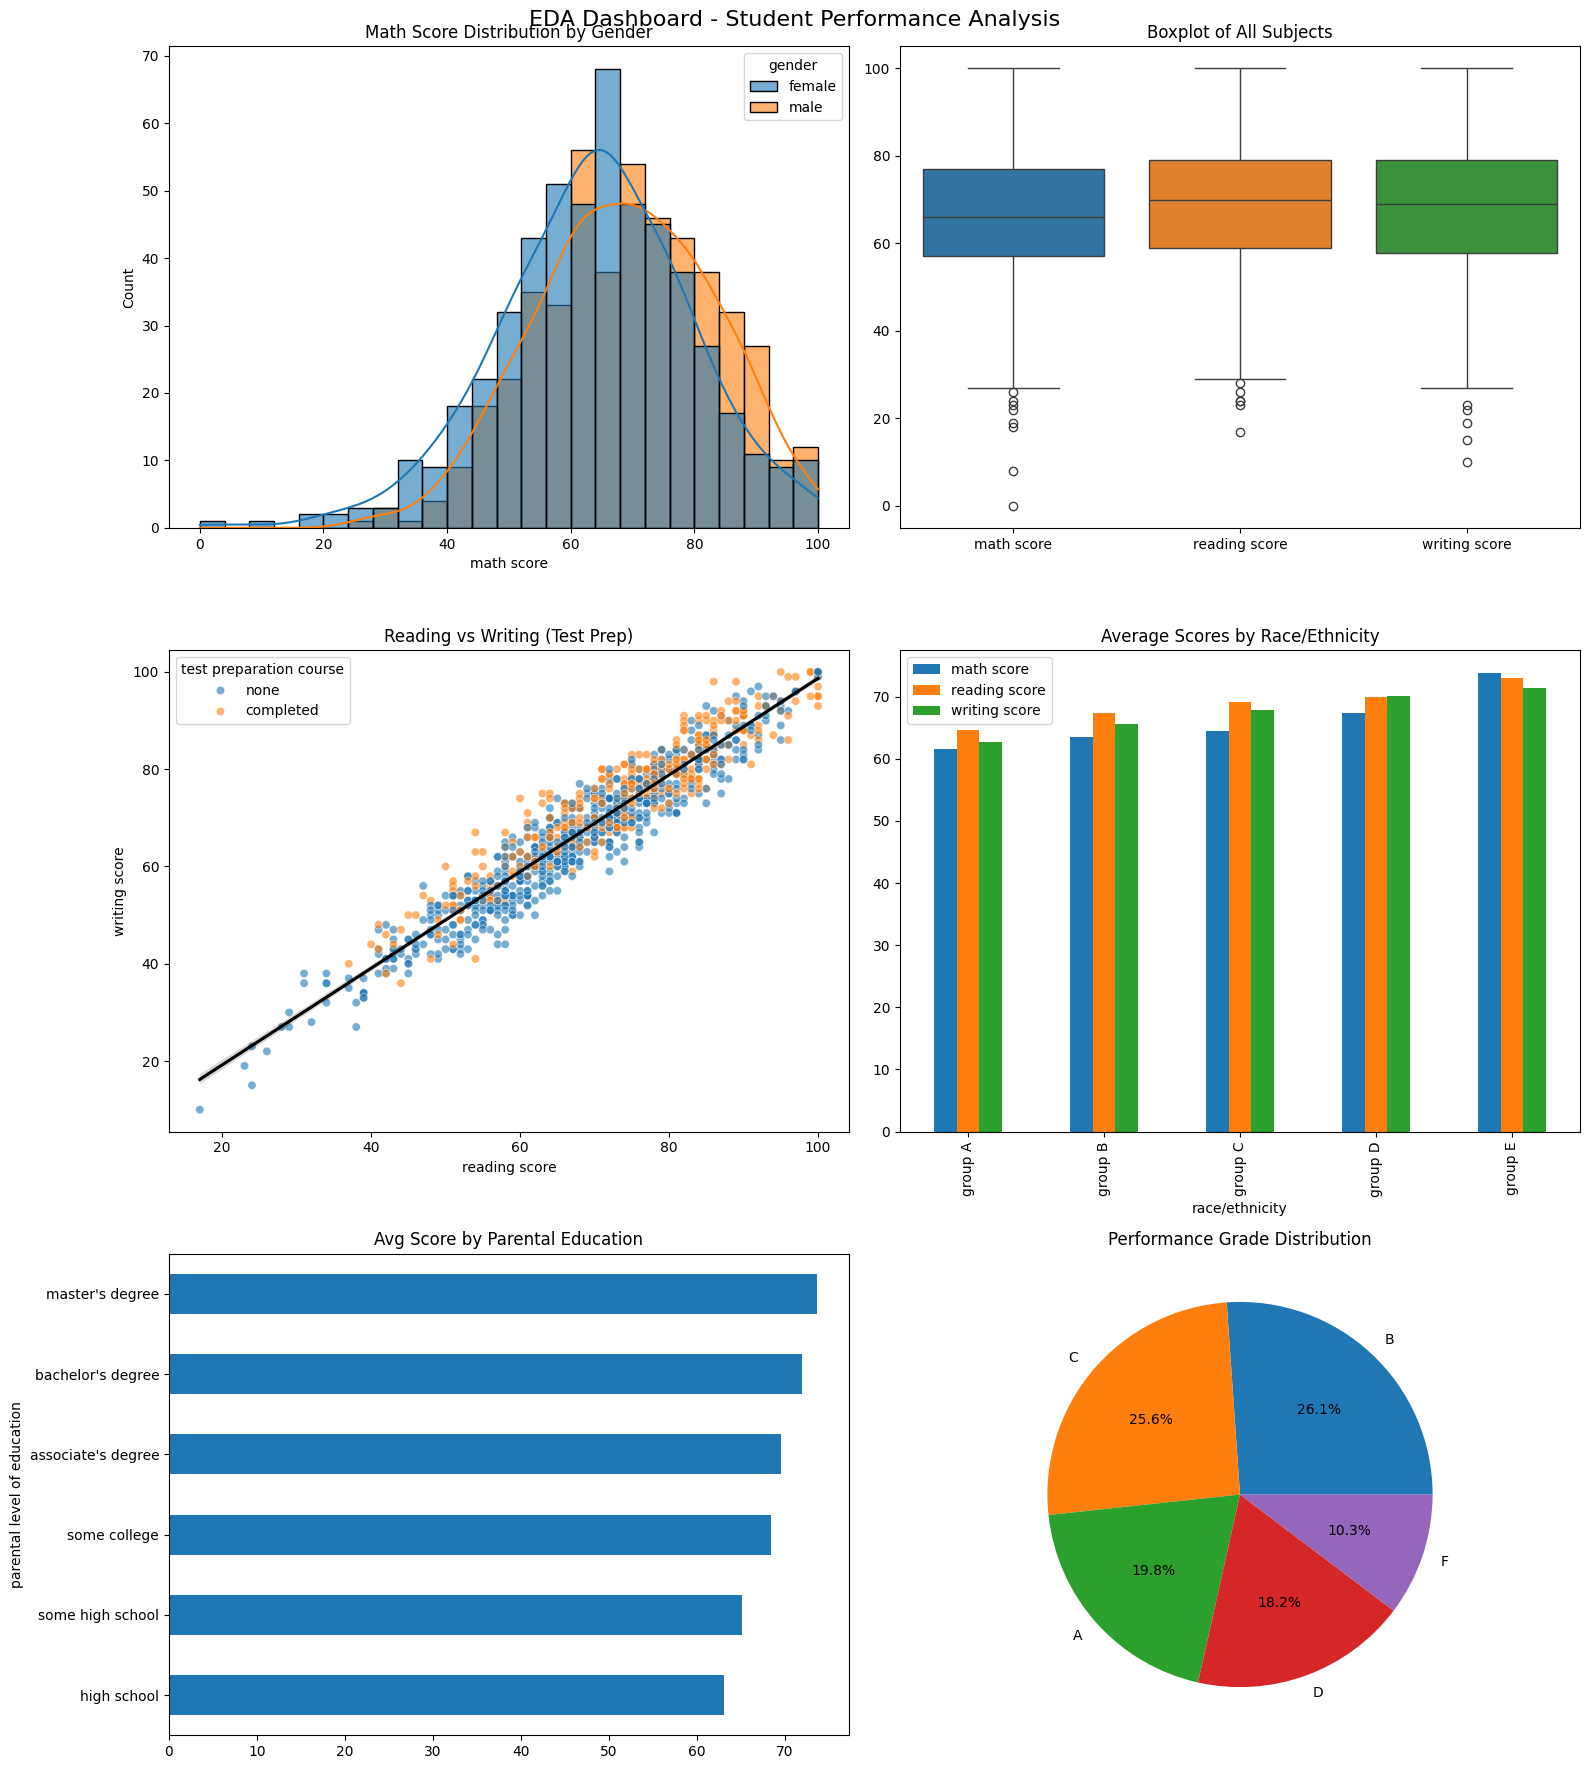

In [38]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# -------------------------
# (1) Histogram + KDE (Math by gender)
# -------------------------
sns.histplot(data=df, x='math score', hue='gender', kde=True, ax=axes[0, 0], alpha=0.6)
axes[0, 0].set_title("Math Score Distribution by Gender")

# -------------------------
# (2) Boxplot (all subjects)
# -------------------------
sns.boxplot(data=df[['math score', 'reading score', 'writing score']], ax=axes[0, 1])
axes[0, 1].set_title("Boxplot of All Subjects")

# -------------------------
# (3) Scatter: reading vs writing + regression
# -------------------------
sns.scatterplot(
    data=df,
    x='reading score',
    y='writing score',
    hue='test preparation course',
    ax=axes[1, 0],
    alpha=0.6
)
sns.regplot(
    data=df,
    x='reading score',
    y='writing score',
    scatter=False,
    ax=axes[1, 0],
    color='black'
)
axes[1, 0].set_title("Reading vs Writing (Test Prep)")

# -------------------------
# (4) Grouped bar: race vs subjects
# -------------------------
race_avg = df.groupby('race/ethnicity')[['math score', 'reading score', 'writing score']].mean()
race_avg.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title("Average Scores by Race/Ethnicity")

# -------------------------
# (5) Horizontal bar: parental education
# -------------------------
parent_avg = df.groupby('parental level of education')['average_score'].mean().sort_values()
parent_avg.plot(kind='barh', ax=axes[2, 0])
axes[2, 0].set_title("Avg Score by Parental Education")

# -------------------------
# (6) Pie chart: grade distribution
# -------------------------
grade_counts = df['performance_grade'].value_counts()
axes[2, 1].pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%')
axes[2, 1].set_title("Performance Grade Distribution")

# -------------------------
# Layout + Save
# -------------------------
plt.suptitle("EDA Dashboard - Student Performance Analysis", fontsize=16)
plt.tight_layout()
plt.savefig("eda_dashboard.png", dpi=150)
plt.show()

## 1. Executive Summary

This analysis explores student performance across math, reading, and writing using a structured dataset of 1000 students. The primary goal is to understand how different factors such as gender, parental education, test preparation, and socioeconomic indicators influence academic performance. The results show that reading and writing scores are generally higher than math scores, and test preparation has a strong positive impact on performance. Gender differences are also observed, with females performing better in reading and writing, while males perform slightly better in math. Overall, the dataset reveals meaningful patterns that can guide educational improvements and targeted interventions for students.

---

## 2. Data Quality Assessment

The dataset is of high quality with no missing values or duplicate records, indicating strong data integrity. All columns are correctly structured, with appropriate data types for categorical and numerical variables. The score columns (math, reading, writing) are clean and fall within a valid range of 0 to 100. Categorical variables such as gender, parental education, and test preparation are well-defined and consistent. Since no preprocessing issues such as missing data or incorrect types were found, the dataset is ready for analysis without requiring significant cleaning steps. However, encoding will still be required for machine learning applications.

---

## 3. Key Statistical Findings

The statistical analysis shows that the average scores are relatively balanced across subjects, with reading having the highest mean and math the lowest. Reading scores average around 69, while math averages around 66, and writing around 68. Standard deviation values are similar across all subjects, indicating consistent variability. A significant portion of students score above 70 in reading and writing compared to math, highlighting that math is the most challenging subject. Correlation analysis reveals a strong relationship between reading and writing (0.95), suggesting that language skills are closely linked. Math shows a slightly weaker correlation with the other subjects but still remains positively related.

---

## 4. Visualization Insights

Visual analysis through histograms, boxplots, scatter plots, and heatmaps provides deeper insights into the dataset. Histograms show that most students cluster around mid-range scores with a slight skew toward higher performance in reading and writing. Boxplots reveal that all three subjects have similar spread, but math has more low-score outliers. Scatter plots show strong linear relationships between reading and writing, especially among students who completed test preparation. Heatmaps confirm high correlation between reading and writing scores. The dashboard visualization clearly shows that language-based subjects behave more consistently compared to math, which exhibits higher variability.

---

## 5. Feature Engineering Rationale

New features such as total score, average score, performance grade, high achiever status, and lowest subject were created to simplify interpretation of student performance. Total and average scores provide a single measure of overall academic performance. Performance grades convert numeric scores into categorical labels, making interpretation easier. The high achiever flag helps identify top-performing students, while lowest subject highlights areas of weakness for each student. These engineered features are useful for both descriptive analysis and potential machine learning applications, as they transform raw data into meaningful insights.

---

## 6. Actionable Recommendations for Educators

Based on the analysis, several actionable insights can be derived. First, additional support should be provided in mathematics, as it has the lowest average score and pass rate among all subjects. Second, test preparation programs should be encouraged, as students who complete them show significantly higher performance across all subjects, especially in writing and reading. Third, targeted interventions can be designed for students who consistently score below 70, particularly in math. Fourth, parental involvement programs may be beneficial, as higher parental education levels are associated with better student outcomes. Lastly, gender-based performance differences suggest that teaching strategies may need to be diversified to support balanced learning across subjects.

---

## 7. Reflection & Lessons Learned

This analysis demonstrates the importance of exploratory data analysis in understanding student performance patterns. Through statistical analysis and visualization, clear relationships between variables such as test preparation, parental education, and academic performance were identified. One key lesson is that raw data alone does not provide meaningful insights without proper transformation and visualization. Feature engineering significantly improves interpretability and supports deeper analysis. Additionally, correlation does not imply causation, so findings must be interpreted carefully. Overall, this project highlights how data-driven approaches can support educational decision-making and improve learning outcomes.